# IT3051 Fundamentals of Data Mining — Algorithm 4: Agglomerative Hierarchical Clustering

## Project: Soft E-commerce Customer Segmentation and Retention Prioritization

### Purpose and Overview
This notebook implements **Agglomerative Hierarchical Clustering** to investigate hierarchical relationships, taxonomic cluster structures, and linkage criteria (Ward, Complete, Average).

### Critical Group Constraints
- **DO NOT independently re-split the original dataset.**
- **DO NOT re-scale or modify features independently.**
- All models must consume the shared preprocessed data produced by `01_EDA_Preprocessing.ipynb`:
  - `data/processed/development_preprocessed.csv` (40,000 customers, 18 features + `customer_id`)
  - `data/processed/holdout_preprocessed.csv` (10,000 customers, 18 features + `customer_id`)
- `customer_id` is for alignment only and **MUST NOT** be passed to the clustering algorithm:
  ```python
  X_dev = development_preprocessed.drop(columns=["customer_id"])
  ```
- Business variables (`customer_lifetime_value_usd`, `churn_risk_score`) are deliberately kept outside clustering and stored in `development_business_data.csv`.

---
*Execution scope and results are stated below; no full-development or holdout labels are implied.*


In [1]:
# Setup and imports
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Resolve project directories
current_dir = Path.cwd().resolve()
PROJECT_ROOT = current_dir.parent if current_dir.name == "notebooks" else current_dir
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"

print("Project root:", PROJECT_ROOT)
print("Processed data dir:", PROCESSED_DATA_DIR)
# Ready to load shared data:
# df_dev = pd.read_csv(PROCESSED_DATA_DIR / "development_preprocessed.csv")
# X_dev = df_dev.drop(columns=["customer_id"])



mkdir -p failed for path C:\Users\User\AppData\Local\matplotlib: [WinError 5] Access is denied: 'C:\\Users\\User\\AppData\\Local\\matplotlib'


Matplotlib created a temporary cache directory at C:\Users\User\AppData\Local\Temp\matplotlib-hdjkcu6n because there was an issue with the default path (C:\Users\User\AppData\Local\matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Project root: C:\Users\User\Desktop\FDM_Ptoj\soft-ecommerce-customer-segmentation
Processed data dir: C:\Users\User\Desktop\FDM_Ptoj\soft-ecommerce-customer-segmentation\data\processed


## 1. Dinethya's objective and execution scope

Agglomerative clustering starts with each customer alone and repeatedly merges the nearest groups. A linkage rule defines the distance between groups. Ward merges to minimise the increase in within-group squared Euclidean variation; complete uses the farthest pair; average uses the mean pairwise distance. We investigate **only Agglomerative** structures on the existing development features. The initial fixed modelling scope is a reproducible sample of 2,500 of the 40,000 development customers. The 10,000 holdout rows are checked for schema and IDs only. No model here can natively predict unseen holdout labels.


In [2]:
import sys, json, time, platform
from importlib import metadata
import psutil
import scipy, sklearn, matplotlib, nbclient, nbformat, docx
import joblib
from IPython.display import Image as NotebookImage, display
from scipy.cluster.hierarchy import cut_tree
from sklearn.metrics import calinski_harabasz_score, adjusted_rand_score

RESULTS_DIR = PROJECT_ROOT / "results" / "agglomerative"
AG_FIGURES_DIR = PROJECT_ROOT / "results" / "figures" / "agglomerative"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
AG_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

VERSIONS = {"python": platform.python_version(), "numpy": np.__version__,
            "pandas": pd.__version__, "scipy": scipy.__version__,
            "scikit-learn": sklearn.__version__, "matplotlib": matplotlib.__version__,
            "nbclient": nbclient.__version__, "nbformat": nbformat.__version__,
            "ipykernel": metadata.version("ipykernel"), "python-docx": metadata.version("python-docx")}
KERNEL_NAME = "agglomerative-local"
print("Interpreter:", sys.executable)
print("Kernel:", KERNEL_NAME)
print("Versions:", VERSIONS)
print("Project root:", PROJECT_ROOT)


Interpreter: C:\Users\User\Desktop\FDM_Ptoj\soft-ecommerce-customer-segmentation\.venv\Scripts\python.exe
Kernel: agglomerative-local
Versions: {'python': '3.14.0', 'numpy': '2.5.3', 'pandas': '3.0.6', 'scipy': '1.18.1', 'scikit-learn': '1.9.1', 'matplotlib': '3.11.2', 'nbclient': '0.11.0', 'nbformat': '5.11.1', 'ipykernel': '7.4.0', 'python-docx': '1.2.0'}
Project root: C:\Users\User\Desktop\FDM_Ptoj\soft-ecommerce-customer-segmentation


## 2. Load and validate the shared data

The split, scaling, and encoding were completed in `01_EDA_Preprocessing.ipynb`; they are not repeated here. `customer_id` is an alignment key only. CLV, churn risk, and profile labels must not enter `X`. Holdout is read solely to verify its schema and IDs.


In [3]:
dev = pd.read_csv(PROCESSED_DATA_DIR / "development_preprocessed.csv")
holdout = pd.read_csv(PROCESSED_DATA_DIR / "holdout_preprocessed.csv")
assert dev.shape == (40_000, 19), dev.shape
assert holdout.shape == (10_000, 19), holdout.shape
assert dev.columns.tolist() == holdout.columns.tolist()
assert dev.columns[0] == "customer_id"
assert dev.customer_id.notna().all() and holdout.customer_id.notna().all()
assert dev.customer_id.is_unique and holdout.customer_id.is_unique
assert set(dev.customer_id).isdisjoint(set(holdout.customer_id))
feature_names = dev.columns.drop("customer_id").tolist()
assert len(feature_names) == 18
assert all(pd.api.types.is_numeric_dtype(dev[c]) and pd.api.types.is_numeric_dtype(holdout[c]) for c in feature_names)
assert not any("churn" in c.lower() or "lifetime_value" in c.lower() or c == "customer_id" for c in feature_names)
X_dev = dev[feature_names].to_numpy(dtype=np.float64)
X_holdout_validation = holdout[feature_names].to_numpy(dtype=np.float64)
assert np.isfinite(X_dev).all() and np.isfinite(X_holdout_validation).all()
del X_holdout_validation
print("Development:", dev.shape, "Holdout:", holdout.shape)
print("Unique non-overlapping IDs:", dev.customer_id.nunique(), holdout.customer_id.nunique())
print("Finite numeric feature count:", len(feature_names), "dtype:", X_dev.dtype)
print("Ordered features:", feature_names)


Development: (40000, 19) Holdout: (10000, 19)
Unique non-overlapping IDs: 40000 10000
Finite numeric feature count: 18 dtype: float64
Ordered features: ['tenure_months', 'total_purchases', 'avg_order_value_usd', 'days_since_last_purchase', 'return_count', 'complaint_count', 'satisfaction_score', 'email_open_rate', 'click_through_rate', 'conversion_rate', 'shopping_channel_In-Store', 'shopping_channel_Marketplace', 'shopping_channel_Mobile App', 'shopping_channel_Online', 'device_used_Desktop', 'device_used_Mobile', 'device_used_Multiple', 'device_used_Tablet']


## 3. Fixed development sample and memory assessment

The shared development set contains **40,000 customers**. A dense hierarchy on all 40,000 would need about **6.40 GB** just for a condensed float64 pairwise distance array, before linkage work arrays, data frames, the kernel, and the operating system. The notebook measures available RAM at execution and compares it with this lower bound plus a 50% working margin. If that budget is unavailable, a full-data fit is unsafe and is not attempted. We use one simple random sample without replacement of exactly **2,500 development customers** (seed 42). This leaves **37,500 development customers without Agglomerative assignments**. We compare feature means and quartiles to check gross sample bias; this cannot establish that rare patterns are represented.


In [4]:
SAMPLE_N, SAMPLE_SEED = 2_500, 42
SILHOUETTE_N, SILHOUETTE_SEED = SAMPLE_N, None
full_condensed_distance_gb = (len(dev) * (len(dev) - 1) // 2 * 8) / 1e9
available_gb = psutil.virtual_memory().available / 1e9
full_fit_working_budget_gb = 1.5 * full_condensed_distance_gb
full_fit_memory_safe = available_gb >= full_fit_working_budget_gb
assert available_gb >= 2.0, f"Only {available_gb:.2f} GB free; stop and reassess manually."
sample_positions = np.sort(np.random.default_rng(SAMPLE_SEED).choice(len(dev), SAMPLE_N, replace=False))
sample = dev.iloc[sample_positions].reset_index(drop=True)
sample_ids = sample.customer_id.to_numpy()
X_sample = sample[feature_names].to_numpy(dtype=np.float64)
full_means, full_std = X_dev.mean(axis=0), X_dev.std(axis=0)
sample_means = X_sample.mean(axis=0)
rep = pd.DataFrame({"feature": feature_names, "development_mean": full_means,
                    "sample_mean": sample_means, "development_std": full_std,
                    "absolute_standardized_mean_difference": np.divide(abs(sample_means-full_means), full_std,
                                                           out=np.zeros_like(full_std), where=full_std>0)})
for q in (0.25, 0.75):
    rep[f"development_q{int(q*100)}"] = np.quantile(X_dev, q, axis=0)
    rep[f"sample_q{int(q*100)}"] = np.quantile(X_sample, q, axis=0)
rep.to_csv(RESULTS_DIR / "agglomerative_sample_representativeness.csv", index=False)
print("Sample method: simple random without replacement; seed:", SAMPLE_SEED)
print("Sample size:", SAMPLE_N, "IDs recorded with selected assignments; free RAM (GB):", round(available_gb, 2))
print("Full-development condensed distance lower bound (GB):", round(full_condensed_distance_gb, 2))
print("Full-fit working budget with 50% margin (GB):", round(full_fit_working_budget_gb, 2))
print("Safe to attempt full dense fit under this budget:", full_fit_memory_safe)
print("Full-data fit attempted: False; unlabeled development customers:", len(dev) - SAMPLE_N)
print("Largest absolute standardized mean difference:", round(rep.absolute_standardized_mean_difference.max(), 4))
display(rep.round(4))


Sample method: simple random without replacement; seed: 42
Sample size: 2500 IDs recorded with selected assignments; free RAM (GB): 4.46
Full-development condensed distance lower bound (GB): 6.4
Full-fit working budget with 50% margin (GB): 9.6
Safe to attempt full dense fit under this budget: False
Full-data fit attempted: False; unlabeled development customers: 37500
Largest absolute standardized mean difference: 0.0379


,feature,development_mean,sample_mean,development_std,absolute_standardized_mean_difference,development_q25,sample_q25,development_q75,sample_q75
0,tenure_months,0.0000,0.0023,1.0000,0.0023,-0.8655,-0.8655,0.8557,0.8629
1,total_purchases,-0.0000,-0.0379,1.0000,0.0379,-0.8734,-0.8907,0.8734,0.8042
2,avg_order_value_usd,-0.0000,0.0187,1.0000,0.0187,-0.8618,-0.8535,0.8642,0.8933
3,days_since_last_purchase,0.0000,0.0133,1.0000,0.0133,-0.6529,-0.6529,0.1428,0.1455
4,return_count,0.0000,0.0209,1.0000,0.0209,-0.9528,-0.7800,0.9474,0.9474
5,complaint_count,-0.0000,-0.0017,1.0000,0.0017,-0.9237,-0.9237,0.9257,0.9257
6,satisfaction_score,0.0000,0.0085,1.0000,0.0085,-0.7137,-0.7137,0.6980,0.6980
7,email_open_rate,-0.0000,-0.0091,1.0000,0.0091,-0.8672,-0.8620,0.8698,0.8905
8,click_through_rate,0.0000,-0.0185,1.0000,0.0185,-0.8552,-0.8847,0.8652,0.8305
9,conversion_rate,-0.0000,0.0236,1.0000,0.0236,-0.8692,-0.8692,0.8690,0.9036


## 4. Predeclared scikit-learn baseline

The baseline is `AgglomerativeClustering(n_clusters=3, linkage='ward', metric='euclidean')` on the fixed 2,500-row development sample. It is a reference point, **not** a chosen winner. **Every Silhouette score uses all 2,500 fitted customers**, with the configuration's own distance metric; Davies–Bouldin and Calinski–Harabasz also use all 2,500. A cluster under 1% is recorded as a size warning independently of metric validity.


In [5]:
def score_labels(labels, distance):
    """Score the full fixed sample; keep small-cluster warnings separate."""
    labels = np.asarray(labels)
    assert len(labels) == SAMPLE_N, "All scores must use the fixed 2,500-customer sample"
    counts = np.bincount(labels)
    counts = counts[counts > 0]
    n_clusters = len(counts)
    warning = "cluster below 1%" if len(counts) and counts.min() / SAMPLE_N < 0.01 else None
    if not 2 <= n_clusters <= SAMPLE_N - 1:
        return None, f"metrics require 2 to n-1 clusters; got {n_clusters}", warning, SAMPLE_N
    scores = {"silhouette": float(silhouette_score(X_sample, labels, metric=distance)),
              "davies_bouldin": float(davies_bouldin_score(X_sample, labels)),
              "calinski_harabasz": float(calinski_harabasz_score(X_sample, labels))}
    if not all(np.isfinite(value) for value in scores.values()):
        return None, "non-finite validation metric", warning, SAMPLE_N
    return scores, None, warning, SAMPLE_N

t0 = time.perf_counter()
baseline_model = AgglomerativeClustering(n_clusters=3, linkage="ward", metric="euclidean")
baseline_labels = baseline_model.fit_predict(X_sample)
baseline_fit_s = time.perf_counter() - t0
baseline_scores, baseline_error, baseline_warning, baseline_eval_n = score_labels(baseline_labels, "euclidean")
assert baseline_error is None, baseline_error
baseline_counts = np.bincount(baseline_labels).tolist()
baseline_record = {"K": 3, "linkage": "ward", "metric": "euclidean", "sample_n": SAMPLE_N,
                   "sample_seed": SAMPLE_SEED, "silhouette_eval_n": baseline_eval_n,
                   "actual_clusters": len(baseline_counts),
                   "cluster_counts": json.dumps(baseline_counts),
                   "cluster_percentages": json.dumps((100*np.bincount(baseline_labels)/SAMPLE_N).round(3).tolist()),
                   **baseline_scores, "fit_runtime_s": baseline_fit_s}
pd.DataFrame([baseline_record]).to_csv(RESULTS_DIR / "agglomerative_baseline_sample_metrics.csv", index=False)
print("Baseline (not selected):", baseline_record)


Baseline (not selected): {'K': 3, 'linkage': 'ward', 'metric': 'euclidean', 'sample_n': 2500, 'sample_seed': 42, 'silhouette_eval_n': 2500, 'actual_clusters': 3, 'cluster_counts': '[1229, 375, 896]', 'cluster_percentages': '[49.16, 15.0, 35.84]', 'silhouette': 0.04511851573494625, 'davies_bouldin': 4.153411179711593, 'calinski_harabasz': 137.99630796154227, 'fit_runtime_s': 0.16135269997175783}


## 5. Linkage and K sweep on the same sample

We predeclare Ward/Euclidean, complete/Euclidean, average/Euclidean, complete/Manhattan, and average/Manhattan for K=2…8. Memory permits the two Manhattan diagnostics on this fixed sample. Ward is Euclidean only. Single linkage is omitted because chaining can merge through isolated bridges and is less useful for compact customer segments; this omission is a design choice, not an empirical finding. One SciPy hierarchy is reused per linkage/distance setting and cut at each K; every cut's actual cluster count is checked. Each row records its tree construction time and cut/evaluation time. Silhouette uses its fitted distance on fixed positions; DB/CH describe feature-space dispersion and need caution for Manhattan fits.


### Choose the sweep settings

**What:** List the five valid linkage and distance settings and K=2 through 8. **Why:** All experiments must use the same declared search space. **Output:** Configuration lists and empty result containers.

In [6]:
CONFIGS = [("ward", "euclidean"), ("complete", "euclidean"), ("average", "euclidean"),
           ("complete", "manhattan"), ("average", "manhattan")]
KS = range(2, 9)
trees, cut_labels, experiment_rows = {}, {}, []
tree_runtimes, tree_errors = {}, {}


### Build one tree for each setting

**What:** Fit each hierarchy once and time its construction. **Why:** One tree can be cut at several K values without fitting it again. **Output:** Five trees, or a recorded tree error.

In [7]:
for link, distance in CONFIGS:
    tree_start = time.perf_counter()
    try:
        tree = linkage(X_sample, method=link, metric="cityblock" if distance == "manhattan" else distance)
        tree_runtime = time.perf_counter() - tree_start
        trees[(link, distance)] = tree
    except Exception as exc:
        tree_runtime = time.perf_counter() - tree_start
        tree = None
        tree_error = f"{type(exc).__name__}: {exc}"
    tree_runtimes[(link, distance)] = tree_runtime
    if tree is None:
        tree_errors[(link, distance)] = tree_error


### Cut each tree and score K=2 through 8

**What:** Make seven cuts per setting, count cluster sizes, and calculate the three metrics. **Why:** The 35 cuts provide comparable evidence on the fixed sample. **Output:** Experiment rows and a separate warning for clusters below 1%.

In [8]:
for link, distance in CONFIGS:
    tree = trees.get((link, distance))
    tree_runtime = tree_runtimes[(link, distance)]
    if tree is None:
        tree_error = tree_errors[(link, distance)]
    for k in KS:
        row = {"K": k, "linkage": link, "metric": distance, "sample_n": SAMPLE_N,
               "sample_seed": SAMPLE_SEED, "silhouette_eval_n": SILHOUETTE_N,
               "silhouette_eval_seed": SILHOUETTE_SEED, "actual_clusters": np.nan,
               "cluster_counts": None, "cluster_percentages": None, "min_cluster_pct": np.nan,
               "silhouette": np.nan, "davies_bouldin": np.nan, "calinski_harabasz": np.nan,
               "tree_runtime_s": tree_runtime, "cut_eval_runtime_s": np.nan, "total_runtime_s": np.nan,
               "failure": None, "cluster_size_warning": None}
        if tree is None:
            row["failure"] = tree_error
            experiment_rows.append(row)
            continue
        cut_start = time.perf_counter()
        try:
            labels = cut_tree(tree, n_clusters=[k]).ravel().astype(int)
            counts = np.bincount(labels)
            counts = counts[counts > 0]
            row["actual_clusters"] = len(counts)
            row["cluster_counts"] = json.dumps(counts.tolist())
            row["cluster_percentages"] = json.dumps((counts/SAMPLE_N*100).round(3).tolist())
            row["min_cluster_pct"] = counts.min()/SAMPLE_N*100
            if row["min_cluster_pct"] < 1:
                row["cluster_size_warning"] = "cluster below 1%"
            if len(counts) != k:
                row["failure"] = f"cut produced {len(counts)} rather than K={k} clusters"
            else:
                cut_labels[(link, distance, k)] = labels
                scores, error, warning, eval_n = score_labels(labels, distance)
                row["silhouette_eval_n"] = eval_n
                row["cluster_size_warning"] = warning
                if error:
                    row["failure"] = error
                else:
                    row.update(scores)
        except Exception as exc:
            row["failure"] = f"{type(exc).__name__}: {exc}"
        row["cut_eval_runtime_s"] = time.perf_counter() - cut_start
        row["total_runtime_s"] = row["tree_runtime_s"] + row["cut_eval_runtime_s"]
        experiment_rows.append(row)
    print("Completed", link, distance, "tree seconds:", round(tree_runtime, 2))


Completed ward euclidean tree seconds: 0.13


Completed complete euclidean tree seconds: 0.14


Completed average euclidean tree seconds: 0.17


Completed complete manhattan tree seconds: 0.13


Completed average manhattan tree seconds: 0.14


### Save and inspect the sweep

**What:** Write the 35 rows and display their main columns. **Why:** The saved table makes every score and warning reviewable. **Output:** The experiment CSV and a compact notebook table.

In [9]:
experiments = pd.DataFrame(experiment_rows)
experiments.to_csv(RESULTS_DIR / "agglomerative_experiment_sample_results.csv", index=False)
display(experiments[["K", "linkage", "metric", "actual_clusters", "min_cluster_pct", "silhouette", "davies_bouldin", "calinski_harabasz", "cluster_size_warning", "failure"]].round(4))
print("Unscored rows:", int(experiments[["silhouette", "davies_bouldin", "calinski_harabasz"]].isna().any(axis=1).sum()))
print("Rows warning of cluster below 1%:", int(experiments.cluster_size_warning.notna().sum()))


,K,linkage,metric,actual_clusters,min_cluster_pct,silhouette,davies_bouldin,calinski_harabasz,cluster_size_warning,failure
0,2,ward,euclidean,2,15.00,0.1243,2.5844,188.3507,NaN,None
1,3,ward,euclidean,3,15.00,0.0451,4.1534,137.9963,NaN,None
2,4,ward,euclidean,4,15.00,0.0358,3.8020,117.3913,NaN,None
3,5,ward,euclidean,5,13.08,0.0296,3.6651,103.6468,NaN,None
4,6,ward,euclidean,6,10.52,0.0267,3.5051,95.3181,NaN,None
5,7,ward,euclidean,7,8.32,0.0237,3.3210,89.3806,NaN,None
6,8,ward,euclidean,8,6.48,0.0218,3.1739,83.9251,NaN,None
7,2,complete,euclidean,2,13.28,0.1264,2.5409,175.3203,NaN,None
8,3,complete,euclidean,3,13.28,0.0316,5.0038,114.7681,NaN,None
9,4,complete,euclidean,4,13.28,0.0182,4.9242,89.1404,NaN,None


Unscored rows: 0
Rows warning of cluster below 1%: 12


## 6. Metric, size, and hierarchy figures

Every Silhouette curve uses the **same full fixed 2,500-customer sample**, evaluated with the fitted configuration's Euclidean or Manhattan distance. Davies–Bouldin and Calinski–Harabasz also use all 2,500 rows. The experiment CSV records `silhouette_eval_n=2500` for every row. Minimum cluster percentage exposes tiny clusters, with a 1% warning reference line. The dendrogram is the **truncated Ward hierarchy** fitted on the sample, not on all 40,000 development customers.


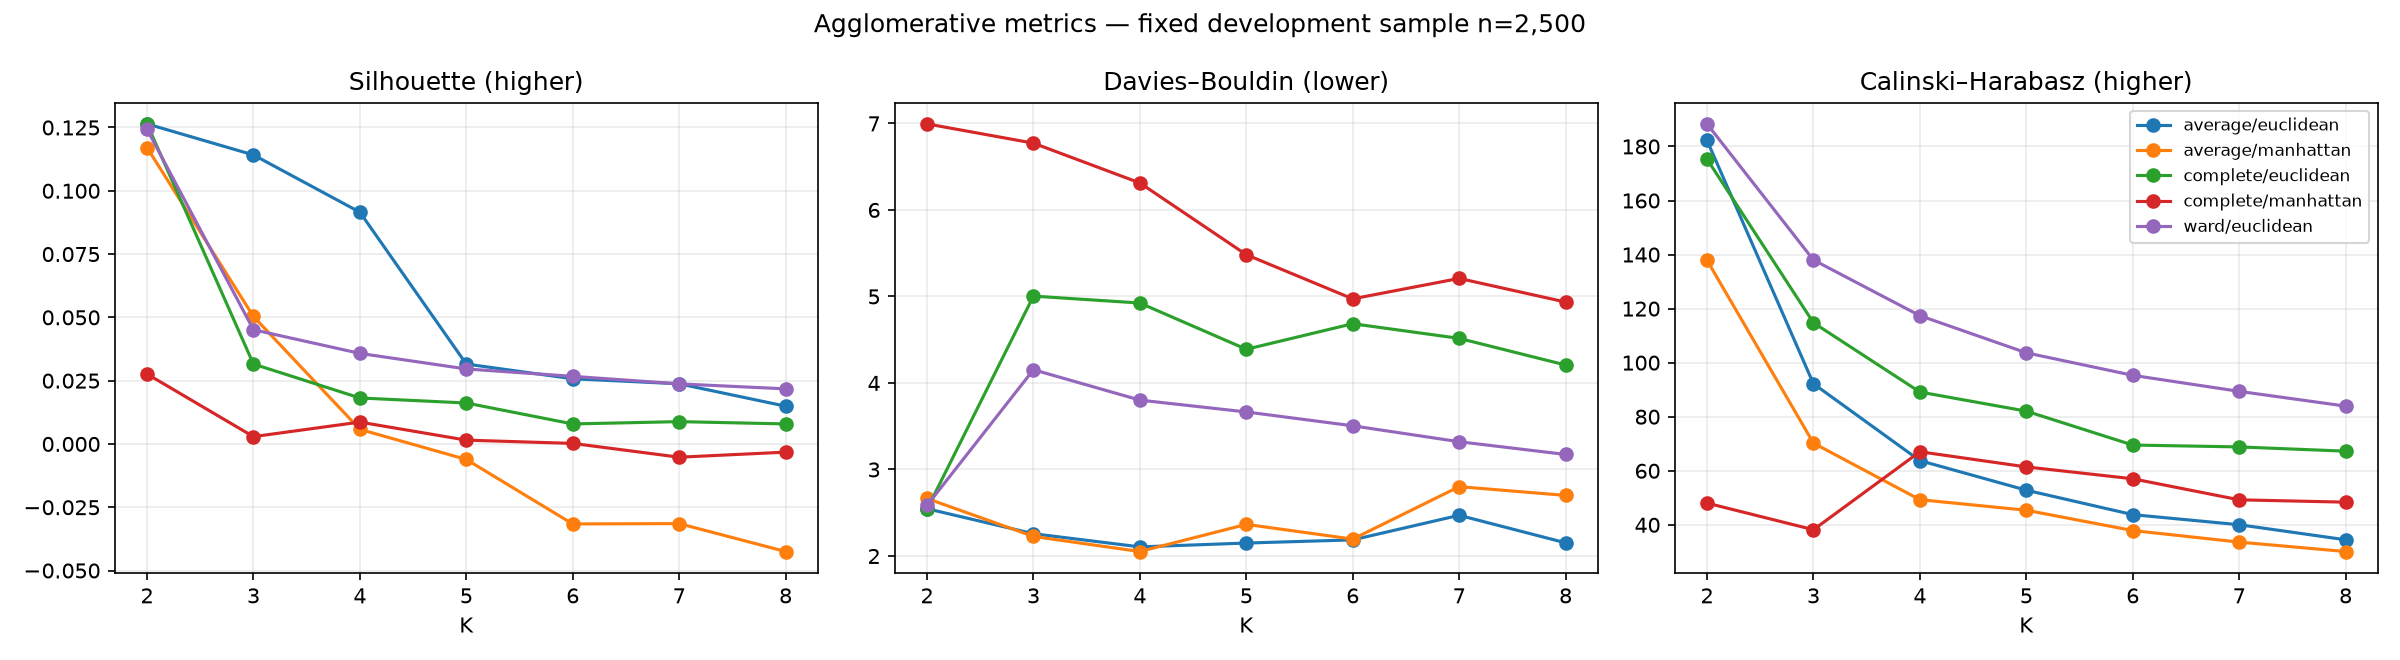

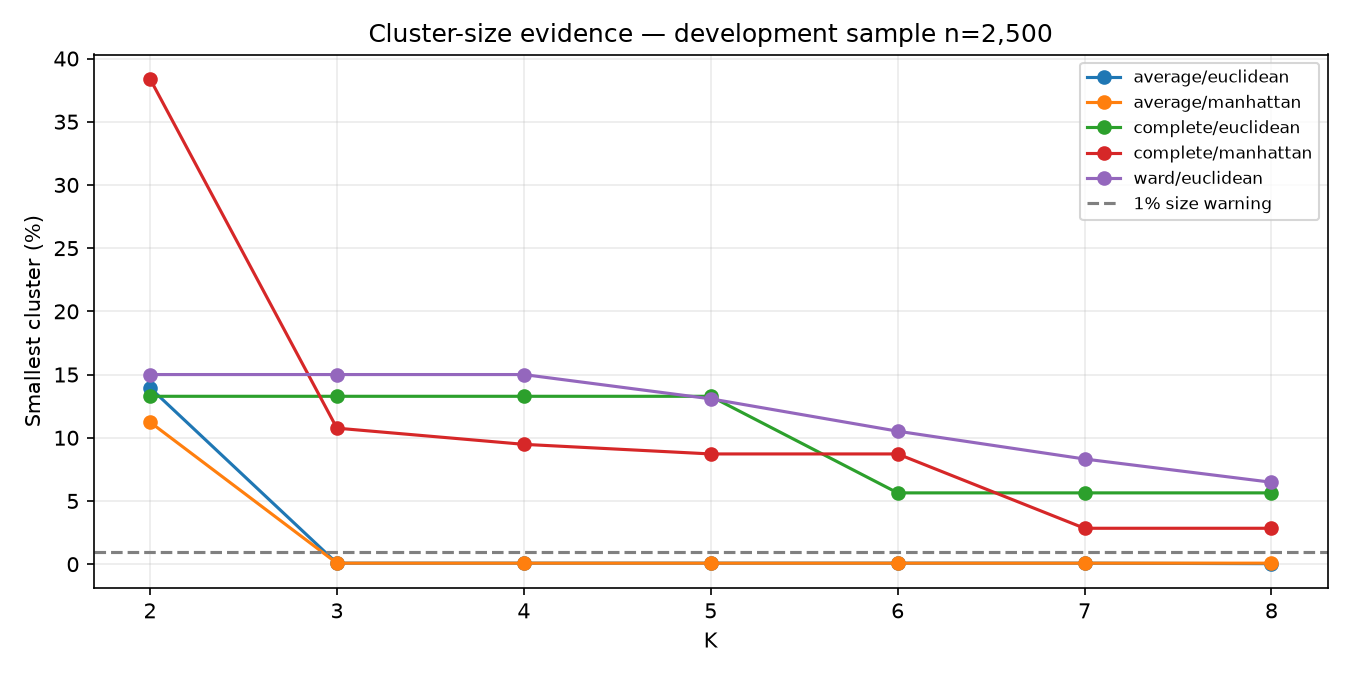

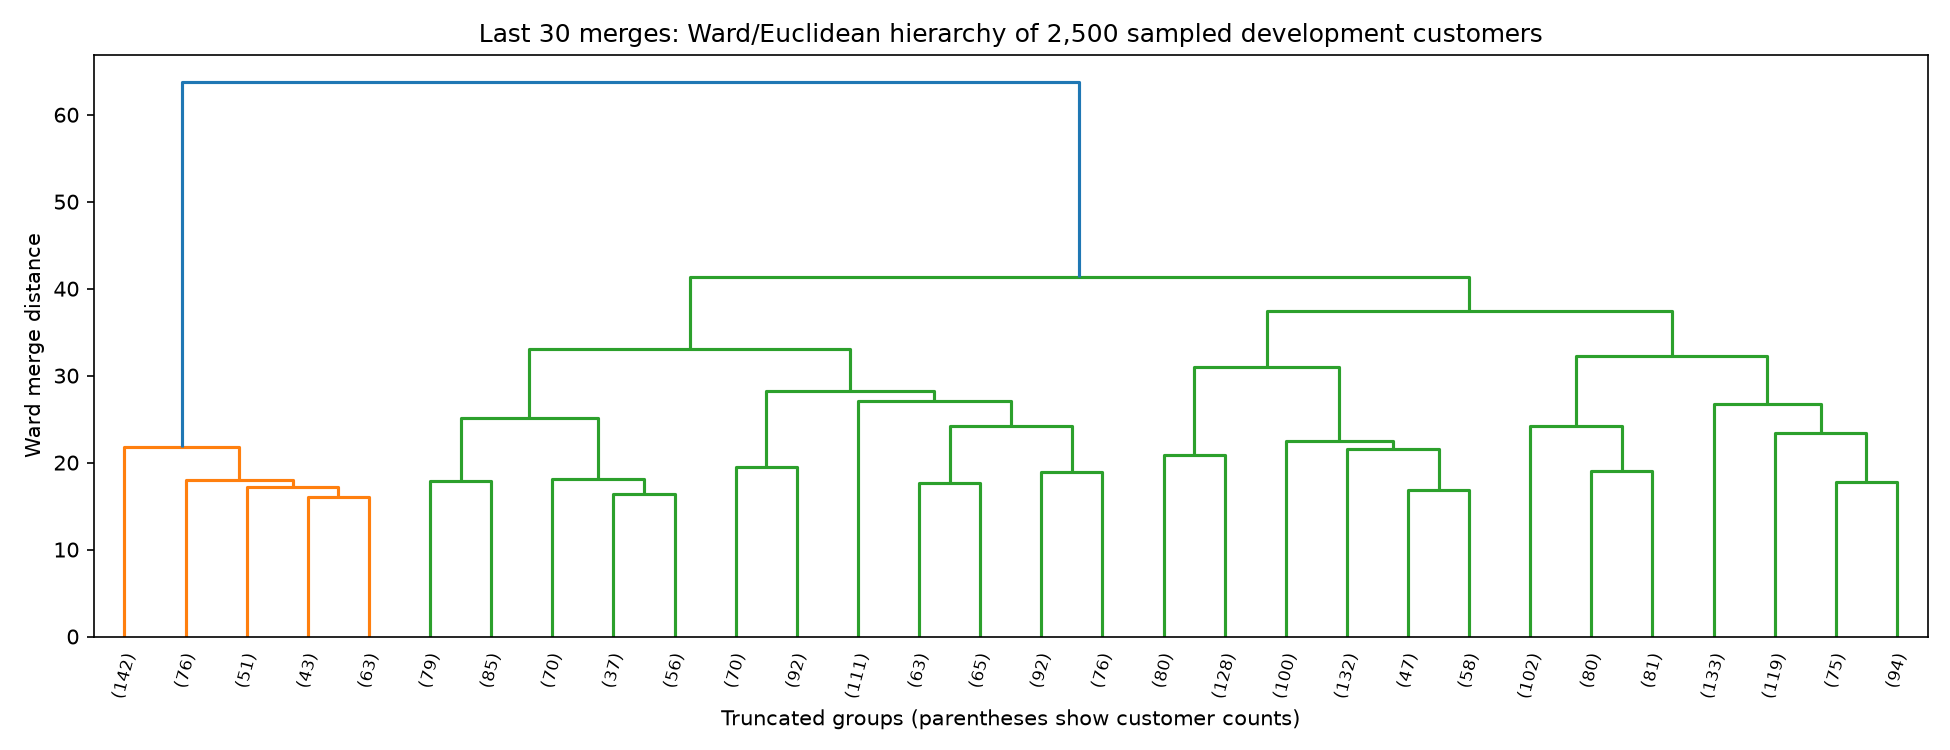

In [10]:
valid_plot = experiments[experiments[["silhouette", "davies_bouldin", "calinski_harabasz"]].notna().all(axis=1)].copy()
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for (link, distance), group in valid_plot.groupby(["linkage", "metric"]):
    for ax, metric_name in zip(axes, ["silhouette", "davies_bouldin", "calinski_harabasz"]):
        ax.plot(group.K, group[metric_name], marker="o", label=f"{link}/{distance}")
for ax, title in zip(axes, ["Silhouette (higher)", "Davies–Bouldin (lower)", "Calinski–Harabasz (higher)"]):
    ax.set_title(title); ax.set_xlabel("K"); ax.set_xticks(list(KS)); ax.grid(alpha=.25)
axes[-1].legend(fontsize=8, loc="best")
fig.suptitle("Agglomerative metrics — fixed development sample n=2,500")
fig.tight_layout()
figure_path = AG_FIGURES_DIR / "agglomerative_sample_metrics_vs_k.png"
fig.savefig(figure_path, dpi=150)
display(NotebookImage(filename=str(figure_path)))
plt.close(fig)

fig, ax = plt.subplots(figsize=(9, 4.5))
for (link, distance), group in experiments.groupby(["linkage", "metric"]):
    ax.plot(group.K, group.min_cluster_pct, marker="o", label=f"{link}/{distance}")
ax.axhline(1, color="gray", linestyle="--", label="1% size warning")
ax.set(xlabel="K", ylabel="Smallest cluster (%)", title="Cluster-size evidence — development sample n=2,500")
ax.set_xticks(list(KS)); ax.grid(alpha=.25); ax.legend(fontsize=8)
fig.tight_layout()
figure_path = AG_FIGURES_DIR / "agglomerative_sample_cluster_sizes_vs_k.png"
fig.savefig(figure_path, dpi=150)
display(NotebookImage(filename=str(figure_path)))
plt.close(fig)

fig, ax = plt.subplots(figsize=(13, 5))
dendrogram(trees[("ward", "euclidean")], truncate_mode="lastp", p=30,
           show_leaf_counts=True, leaf_rotation=75, leaf_font_size=8, ax=ax)
ax.set(xlabel="Truncated groups (parentheses show customer counts)",
       ylabel="Ward merge distance", title="Last 30 merges: Ward/Euclidean hierarchy of 2,500 sampled development customers")
fig.tight_layout()
figure_path = AG_FIGURES_DIR / "agglomerative_sample_ward_dendrogram.png"
fig.savefig(figure_path, dpi=150)
display(NotebookImage(filename=str(figure_path)))
plt.close(fig)


## 7. Meaningful subsample stability

For each linkage/distance setting, the highest-silhouette scored K becomes a candidate. All 35 sweep cuts are considered, including cuts with a cluster below 1%; that size warning remains visible alongside the metrics and is reflected in the selection score's smallest-cluster term. Four seeded, overlapping 80% subsets of the **same 2,500-row sample** are fitted independently with scikit-learn. For each pair, ARI compares labels only on IDs in both subsets; ARI is invariant to arbitrary cluster-number permutations. This measures sensitivity to sampled customers, not seed variation on identical inputs.


### Choose settings for stability checks

**What:** Take the highest-Silhouette scored K for each linkage and distance pair. **Why:** The shortlist limits repeated fits while using all 35 scored cuts. **Output:** Five candidate configurations.

In [11]:
eligible = experiments[experiments[["silhouette", "davies_bouldin", "calinski_harabasz"]].notna().all(axis=1)].copy()
assert len(eligible), "No fully scored sweep candidates; inspect results before selection."
candidates = (eligible.sort_values(["silhouette", "K"], ascending=[False, True])
              .groupby(["linkage", "metric"], sort=False, as_index=False).head(1).copy())


### Fit overlapping subsamples

**What:** Refit each candidate on four fixed 2,000-customer subsets. **Why:** Changing the customers tests sensitivity to sample composition. **Output:** Four fitted runs for each candidate.

In [12]:
SUBSAMPLE_SEEDS = [101, 202, 303, 404]
SUBSAMPLE_N = 2_000
stability_runs = {}
for candidate in candidates.itertuples(index=False):
    runs = {}
    for seed in SUBSAMPLE_SEEDS:
        positions = np.sort(np.random.default_rng(seed).choice(SAMPLE_N, SUBSAMPLE_N, replace=False))
        start = time.perf_counter()
        model = AgglomerativeClustering(n_clusters=int(candidate.K), linkage=candidate.linkage,
                                        metric=candidate.metric)
        labels = model.fit_predict(X_sample[positions])
        runs[seed] = (positions, labels, time.perf_counter()-start)
    stability_runs[(int(candidate.K), candidate.linkage, candidate.metric)] = runs


### Compare the shared customers with ARI

**What:** Compare every pair of fits only on customers present in both subsets. **Why:** Cluster numbers can differ, so ARI measures agreement without matching label names. **Output:** Six ARI values per candidate, a CSV, and a summary table.

In [13]:
stability_rows = []
for candidate in candidates.itertuples(index=False):
    runs = stability_runs[(int(candidate.K), candidate.linkage, candidate.metric)]
    for i, seed_a in enumerate(SUBSAMPLE_SEEDS):
        for seed_b in SUBSAMPLE_SEEDS[i+1:]:
            pos_a, lab_a, sec_a = runs[seed_a]
            pos_b, lab_b, sec_b = runs[seed_b]
            common, idx_a, idx_b = np.intersect1d(pos_a, pos_b, return_indices=True)
            assert len(common) > 1 and np.array_equal(sample_ids[pos_a[idx_a]], sample_ids[pos_b[idx_b]])
            stability_rows.append({"K": int(candidate.K), "linkage": candidate.linkage,
                                   "metric": candidate.metric, "parent_sample_n": SAMPLE_N,
                                   "parent_sample_seed": SAMPLE_SEED, "subsample_n_a": SUBSAMPLE_N,
                                   "subsample_n_b": SUBSAMPLE_N, "seed_a": seed_a, "seed_b": seed_b,
                                   "overlap_n": len(common), "ari_on_common_ids": adjusted_rand_score(lab_a[idx_a], lab_b[idx_b]),
                                   "fit_runtime_a_s": sec_a, "fit_runtime_b_s": sec_b})
    print("Stability fitted:", candidate.linkage, candidate.metric, "K=", candidate.K)
stability = pd.DataFrame(stability_rows)
stability.to_csv(RESULTS_DIR / "agglomerative_stability_sample_results.csv", index=False)
stability_summary = (stability.groupby(["K", "linkage", "metric"], as_index=False)
                     .agg(mean_ari=("ari_on_common_ids", "mean"), min_ari=("ari_on_common_ids", "min"),
                          mean_overlap_n=("overlap_n", "mean")))
display(stability_summary.round(4))


Stability fitted: average euclidean K= 2
Stability fitted: complete euclidean K= 2
Stability fitted: ward euclidean K= 2
Stability fitted: average manhattan K= 2
Stability fitted: complete manhattan K= 2


,K,linkage,metric,mean_ari,min_ari,mean_overlap_n
0,2,average,euclidean,0.4252,0.0000,1599.6667
1,2,average,manhattan,0.1136,-0.0021,1599.6667
2,2,complete,euclidean,0.0062,-0.0178,1599.6667
3,2,complete,manhattan,0.0045,-0.0100,1599.6667
4,2,ward,euclidean,0.8340,0.7820,1599.6667


### Show the stability graph

**What:** Plot the ARI distributions, save the PNG, and display that PNG here. **Why:** The graph stays visible even when Matplotlib uses the Agg backend. **Output:** One embedded stability figure.

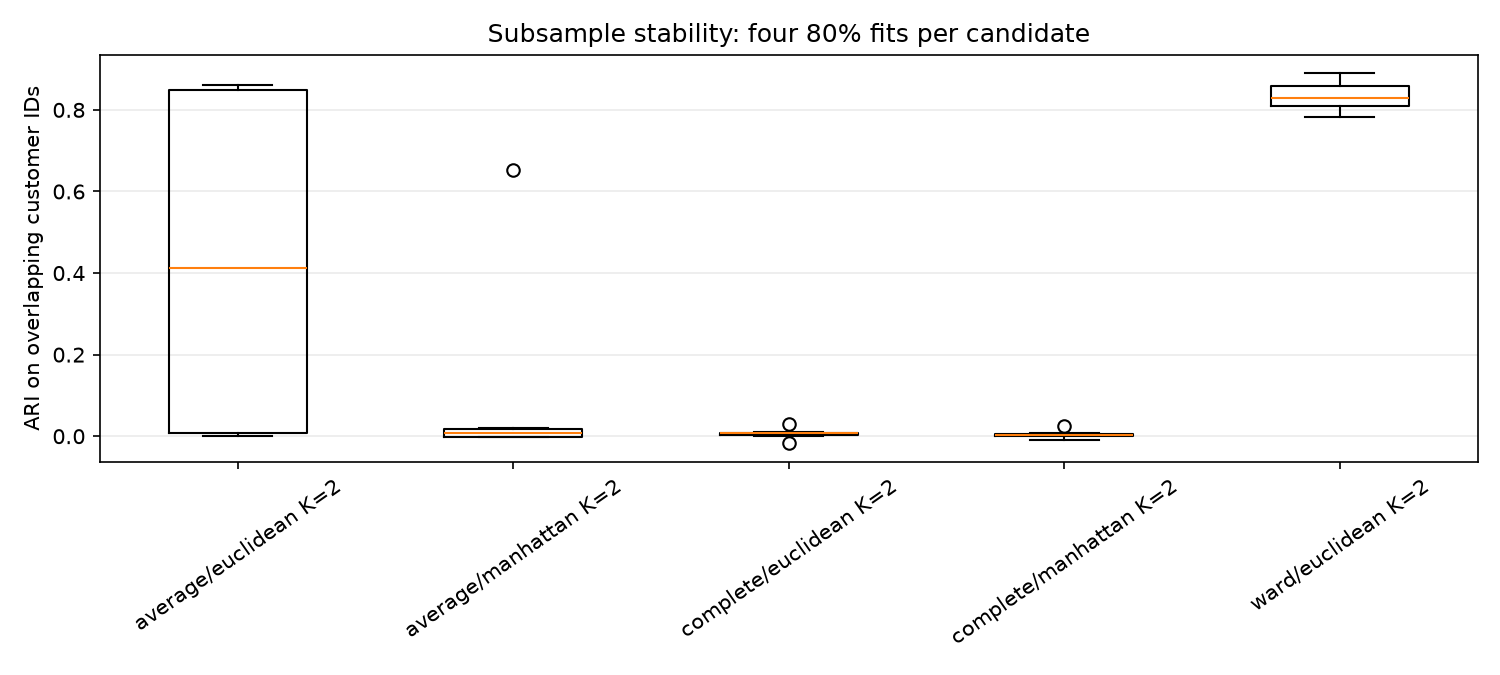

In [14]:
fig, ax = plt.subplots(figsize=(10, 4.5))
groups = list(stability.groupby(["K", "linkage", "metric"]))
ax.boxplot([g.ari_on_common_ids.to_numpy() for _, g in groups], tick_labels=[f"{key[1]}/{key[2]} K={key[0]}" for key, _ in groups])
ax.set(ylabel="ARI on overlapping customer IDs", title="Subsample stability: four 80% fits per candidate")
ax.tick_params(axis="x", labelrotation=35); ax.grid(axis="y", alpha=.25)
fig.tight_layout()
figure_path = AG_FIGURES_DIR / "agglomerative_sample_stability_ari.png"
fig.savefig(figure_path, dpi=150)
display(NotebookImage(filename=str(figure_path)))
plt.close(fig)


## 8. Agglomerative-only selection and exact refit

The stability safeguard was added after an earlier exploratory pass: a candidate must have mean overlapping-subsample ARI at least 0.80 and minimum pairwise ARI at least 0.75 when any candidate passes. This post-hoc threshold makes the choice exploratory and calls for independent validation. Candidate K is chosen from **all 35 fully scored cuts**, including those with a separate small-cluster warning: take the highest-Silhouette K per linkage/metric. Among shortlisted candidates, the selection score ranks Silhouette (30%), overlap stability (30%), smallest-cluster share (15%), Davies–Bouldin (10%), Calinski–Harabasz (5%), runtime (5%), and simpler K (5%). The last two terms are practical and interpretability preferences. CLV, churn and existing labels are excluded. This ranking has subjective weights and does not prove a natural segmentation. Refit the selected setting with scikit-learn on **exactly the same 2,500 sampled IDs** and compare its labels with the SciPy cut by ARI. No unsafe 40,000-row dense refit is attempted.


### Rank the candidates

**What:** Apply the existing weighted score and stability gate. **Why:** Separation, stability, cluster size, and practical costs all inform selection. **Output:** A ranked candidate table with gate flags.

In [15]:
selection = candidates.merge(stability_summary, on=["K", "linkage", "metric"], validate="one_to_one")
selection["selection_score"] = (
    .30*selection.silhouette.rank(pct=True) + .30*selection.mean_ari.rank(pct=True)
    + .15*selection.min_cluster_pct.rank(pct=True) + .10*selection.davies_bouldin.rank(ascending=False, pct=True)
    + .05*selection.calinski_harabasz.rank(pct=True) + .05*selection.total_runtime_s.rank(ascending=False, pct=True)
    + .05*selection.K.rank(ascending=False, pct=True))
selection["stability_gate_pass"] = (selection.mean_ari >= 0.80) & (selection.min_ari >= 0.75)
selection = selection.sort_values(["selection_score", "silhouette"], ascending=False)


### Choose the configuration

**What:** Select the top passing candidate, or the top overall candidate if none pass. **Why:** The rule turns the ranking into one explicit Agglomerative choice. **Output:** The selected linkage, distance, and K.

In [16]:
stable_pool = selection[selection.stability_gate_pass]
selected = (stable_pool if len(stable_pool) else selection).iloc[0]
print("Shortlist and selection ranking:")
display(selection[["K", "linkage", "metric", "silhouette", "min_cluster_pct", "mean_ari", "total_runtime_s", "selection_score", "stability_gate_pass"]].round(4))


Shortlist and selection ranking:


,K,linkage,metric,silhouette,min_cluster_pct,mean_ari,total_runtime_s,selection_score,stability_gate_pass
0,2,average,euclidean,0.1264,13.96,0.4252,0.4053,0.81,False
2,2,ward,euclidean,0.1243,15.00,0.8340,0.3717,0.79,True
1,2,complete,euclidean,0.1264,13.28,0.0062,0.4251,0.60,False
3,2,average,manhattan,0.1171,11.24,0.1136,0.3834,0.46,False
4,2,complete,manhattan,0.0276,38.40,0.0045,0.4414,0.34,False


### Refit and verify the selected sample

**What:** Fit scikit-learn on the same 2,500 IDs and compare labels with the SciPy tree cut. **Why:** This checks that the reported selection matches the saved fitted model. **Output:** Cluster counts, validation metrics, and agreement ARI.

In [17]:
fit_start = time.perf_counter()
selected_model = AgglomerativeClustering(n_clusters=int(selected.K), linkage=selected.linkage,
                                         metric=selected.metric)
selected_labels = selected_model.fit_predict(X_sample)
selected_fit_s = time.perf_counter()-fit_start
selected_scores, selected_error, selected_warning, selected_eval_n = score_labels(selected_labels, selected.metric)
assert selected_error is None, selected_error
selected_counts = np.bincount(selected_labels)
assert len(selected_counts) == int(selected.K)
tree_cut_ari = adjusted_rand_score(cut_labels[(selected.linkage, selected.metric, int(selected.K))], selected_labels)
print("Stability-gate candidates:", len(stable_pool), "(gate was added after initial exploratory run)")
print("Selected sklearn refit:", selected.linkage, selected.metric, "K=", int(selected.K))
print("Actual clusters:", len(selected_counts), "sizes:", selected_counts.tolist())
print("Refit metrics:", selected_scores, "fit seconds:", round(selected_fit_s, 3))
print("SciPy-cut vs sklearn ARI:", round(tree_cut_ari, 6), "(differences can arise at equal-distance ties)")
print("Scope:", SAMPLE_N, "of", len(dev), "development customers assigned;", len(dev)-SAMPLE_N, "remain unlabeled.")


Stability-gate candidates: 1 (gate was added after initial exploratory run)
Selected sklearn refit: ward euclidean K= 2
Actual clusters: 2 sizes: [2125, 375]
Refit metrics: {'silhouette': 0.12429680459010181, 'davies_bouldin': 2.5844023577357045, 'calinski_harabasz': 188.35071578266528} fit seconds: 0.344
SciPy-cut vs sklearn ARI: 1.0 (differences can arise at equal-distance ties)
Scope: 2500 of 40000 development customers assigned; 37500 remain unlabeled.


## 9. Customer-ID joins and post-hoc profiles

Selected labels are joined one-to-one to the shared development raw and profiling files by `customer_id`. Behavioural means and shopping/device proportions explain the groups. Post-selection profiling also summarizes age, gender, activity status, and loyalty tier; these are interpretation only. CLV and churn risk are added only **after** configuration selection, as business context; they cannot influence fitting or ranking. Names remain provisional until a human reviews the profiles.


### Build assignments and customer profiles

**What:** Join selected sample labels to behaviour, demographics, and later business context. **Why:** Profiles explain the groups without using business fields to choose them. **Output:** Exactly 2,500 assignments, cluster sizes, and profiles.

In [18]:
assignments = pd.DataFrame({"customer_id": sample_ids, "cluster": selected_labels,
                            "provisional_cluster_name": [f"Cluster {x} (provisional)" for x in selected_labels]})
assert assignments.customer_id.is_unique and len(assignments) == SAMPLE_N
raw = pd.read_csv(PROCESSED_DATA_DIR / "development_raw.csv")
profiling = pd.read_csv(PROCESSED_DATA_DIR / "development_profiling_data.csv")
business = pd.read_csv(PROCESSED_DATA_DIR / "development_business_data.csv")
for companion in (raw, profiling, business):
    assert companion.customer_id.is_unique
    assert set(sample_ids).issubset(set(companion.customer_id))
joined = assignments.merge(raw, on="customer_id", validate="one_to_one")
joined = joined.merge(profiling, on="customer_id", validate="one_to_one")
assert len(joined) == SAMPLE_N
behavior_numeric = ["tenure_months", "total_purchases", "avg_order_value_usd", "days_since_last_purchase",
                    "return_count", "complaint_count", "satisfaction_score", "email_open_rate",
                    "click_through_rate", "conversion_rate"]
profiles = joined.groupby(["cluster", "provisional_cluster_name"], as_index=False)[behavior_numeric].mean()
for categorical in ["shopping_channel", "device_used"]:
    shares = pd.crosstab(joined.cluster, joined[categorical], normalize="index").add_prefix(categorical+"_pct_")*100
    profiles = profiles.merge(shares.reset_index(), on="cluster", validate="one_to_one")
# Demographic and existing labels remain post-selection interpretation only.
profiles = profiles.merge(joined.groupby("cluster", as_index=False)[["age"]].mean(), on="cluster", validate="one_to_one")
for categorical in ["gender", "activity_status", "loyalty_tier"]:
    shares = pd.crosstab(joined.cluster, joined[categorical], normalize="index").add_prefix(categorical+"_pct_")*100
    profiles = profiles.merge(shares.reset_index(), on="cluster", validate="one_to_one")
# Business measures are joined only now, after labels and model selection are frozen.
business_joined = assignments.merge(business, on="customer_id", validate="one_to_one")
business_means = business_joined.groupby("cluster", as_index=False)[["customer_lifetime_value_usd", "churn_risk_score"]].mean()
profiles = profiles.merge(business_means, on="cluster", validate="one_to_one")
sizes = (assignments.groupby(["cluster", "provisional_cluster_name"], as_index=False)
         .size().rename(columns={"size": "customers"}))
sizes["percent_of_selected_sample"] = sizes.customers / SAMPLE_N * 100
assert sizes.customers.sum() == SAMPLE_N


### Save and show sample profiles

**What:** Write the assignments, sizes, and profiles to their existing CSV paths. **Why:** These files document only the sampled development customers. **Output:** Three CSV files and two notebook tables.

In [19]:
assignments.to_csv(RESULTS_DIR / "agglomerative_selected_sample_assignments.csv", index=False)
sizes.to_csv(RESULTS_DIR / "agglomerative_selected_sample_cluster_sizes.csv", index=False)
profiles.to_csv(RESULTS_DIR / "agglomerative_selected_sample_profiles.csv", index=False)
display(sizes.round(2))
display(profiles.round(2))


,cluster,provisional_cluster_name,customers,percent_of_selected_sample
0,0,Cluster 0 (provisional),2125,85.0
1,1,Cluster 1 (provisional),375,15.0


,cluster,provisional_cluster_name,tenure_months,total_purchases,avg_order_value_usd,days_since_last_purchase,return_count,complaint_count,satisfaction_score,email_open_rate,...,activity_status_pct_At Risk,activity_status_pct_Dormant,activity_status_pct_Inactive,loyalty_tier_pct_Bronze,loyalty_tier_pct_Diamond,loyalty_tier_pct_Gold,loyalty_tier_pct_Platinum,loyalty_tier_pct_Silver,customer_lifetime_value_usd,churn_risk_score
0,0,Cluster 0 (provisional),60.03,98.16,512.35,28.88,9.68,6.97,3.04,0.49,...,12.47,10.78,7.48,8.28,41.74,19.42,22.28,8.28,58443.24,23.32
1,1,Cluster 1 (provisional),58.16,92.50,499.01,262.69,9.36,7.10,2.95,0.52,...,0.00,1.33,98.67,11.35,35.41,19.46,23.78,10.00,51895.20,46.46


### Executed sample result and limitations

The selected Agglomerative setting is **Ward/Euclidean, K=2** on exactly **2,500 sampled development customers**. Its cluster counts are **[2125, 375]** (85% and 15%). With the **same full 2,500-customer sample** used for every Silhouette calculation, its Silhouette is **0.12430**, Davies–Bouldin is **2.58440**, and Calinski–Harabasz is **188.35072**. The Ward/Euclidean K=3 baseline Silhouette is **0.04512**. Mean overlapping-subsample ARI is **0.83402** (minimum **0.78197**), and the SciPy cut agrees with the scikit-learn refit at ARI **1.000**. All **35** sweep rows have all three metrics; **12** average-linkage rows carry a separate warning for a cluster below 1%, and **0** rows remain unscored. The selection did not change after full-sample Silhouette scoring, although the selected Silhouette fell from the earlier 1,200-row estimate of 0.12896. The separation remains modest and the stability safeguard was added after an earlier exploratory pass, so independent validation is needed.

The shared development set has **40,000 customers**. A condensed float64 distance array for a 40,000-customer hierarchy alone requires **6.40 GB**, before fitting overhead; the available RAM measured during each run is recorded in the final sample summary. This notebook uses a reproducible 2,500-customer sample to keep fitting practical under constrained memory and does not attempt a full-data fit. Only the sampled **2,500** have Agglomerative assignments; the other **37,500 development customers** and all holdout customers remain unlabeled. This is a **sample-based Agglomerative result** unless a real full-data fit succeeds.


## 10. Save scope, reproducibility, and holdout limitation

Standard scikit-learn `AgglomerativeClustering` has no native `predict()` for unseen customers. This notebook neither fits holdout separately nor invents holdout labels. The estimator saved as `models/agglomerative_selected_sample_model.pkl` is a **2,500-customer sample hierarchy**, not an unseen-customer predictor. A real 40,000-customer Agglomerative fit was not attempted because the available RAM did not meet the dense-distance lower bound or the working-memory budget. Repeatability depends on the input files, sample IDs, package versions, and recorded seed. The other **37,500 development customers remain unlabeled**. This work is sample-based unless a real full-data fit succeeds.


### Save the summary and reproducibility record

**What:** Write the selection, scope, versions, sample IDs, and experiment settings. **Why:** These records let a reader audit the sample-based result. **Output:** The existing summary CSV/JSON and reproducibility JSON.

In [20]:
summary = {"algorithm": "AgglomerativeClustering", "author": "Dinethya",
           "status": "selected_on_development_sample_only", "development_rows": len(dev),
           "holdout_rows_schema_only": len(holdout), "assignment_rows": len(assignments),
           "sample_method": "simple random without replacement", "sample_seed": SAMPLE_SEED,
           "sample_n": SAMPLE_N, "silhouette_eval_n": SILHOUETTE_N,
           "unlabeled_development_rows": len(dev) - len(assignments),
           "full_development_condensed_distance_gb": full_condensed_distance_gb,
           "available_ram_gb_at_start": available_gb,
           "full_fit_working_budget_gb": full_fit_working_budget_gb,
           "full_fit_memory_safe_under_budget": bool(full_fit_memory_safe),
           "full_development_fit_attempted": False,
           "silhouette_eval_seed": SILHOUETTE_SEED, "baseline": baseline_record,
           "selected_K": int(selected.K), "selected_linkage": selected.linkage, "selected_metric": selected.metric,
           "selected_actual_clusters": int(len(selected_counts)), "selected_cluster_counts": selected_counts.tolist(),
           "selected_silhouette": selected_scores["silhouette"],
           "selected_davies_bouldin": selected_scores["davies_bouldin"],
           "selected_calinski_harabasz": selected_scores["calinski_harabasz"],
           "selected_stability_mean_ari": float(selected.mean_ari),
           "selected_stability_min_ari": float(selected.min_ari),
           "selected_stability_gate_pass": bool(selected.stability_gate_pass),
           "selected_fit_runtime_s": selected_fit_s, "scipy_cut_vs_sklearn_ari": float(tree_cut_ari),
           "sweep_failure_rows": int(experiments[["silhouette", "davies_bouldin", "calinski_harabasz"]].isna().any(axis=1).sum()),
           "sweep_cluster_below_1pct_rows": int(experiments.cluster_size_warning.notna().sum()),
           "sample_representativeness_max_abs_smd": float(rep.absolute_standardized_mean_difference.max()),
           "selection_rule": "One best-silhouette scored K per linkage/metric (including size-warning rows); after initial exploratory run, require mean overlap ARI >= .80 and min ARI >= .75 if any candidate passes; then rank by silhouette .30, ARI .30, min cluster pct .15, DB .10, CH .05, runtime .05, smaller K .05",
           "selection_limit": "Stability gate was added after inspecting first exploratory run; selected configuration needs independent validation",
           "scope_limit": "Sample-based Agglomerative result: assignments cover only 2,500 of 40,000 development customers; 37,500 development and all holdout customers have no Agglomerative labels; no full-data fit succeeded",
           "versions": VERSIONS, "kernel": KERNEL_NAME, "interpreter": sys.executable}
pd.DataFrame([{k: v for k, v in summary.items() if not isinstance(v, (dict, list))}]).to_csv(
    RESULTS_DIR / "agglomerative_final_sample_summary.csv", index=False)
with (RESULTS_DIR / "agglomerative_final_sample_summary.json").open("w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)
repro = {"versions": VERSIONS, "kernel": KERNEL_NAME, "interpreter": sys.executable,
         "cwd": str(Path.cwd()), "sample_method": summary["sample_method"], "sample_seed": SAMPLE_SEED,
         "sample_n": SAMPLE_N, "sample_customer_ids": sample_ids.tolist(),
         "silhouette_eval_seed": SILHOUETTE_SEED, "silhouette_eval_n": SILHOUETTE_N,
         "subsample_seeds": SUBSAMPLE_SEEDS, "subsample_n": SUBSAMPLE_N,
         "configs": CONFIGS, "K_values": list(KS)}
with (RESULTS_DIR / "agglomerative_reproducibility.json").open("w", encoding="utf-8") as f:
    json.dump(repro, f, indent=2)


### Save the fitted sample model

**What:** Serialize the already fitted selected model to its existing .pkl path. **Why:** The artifact stores the 2,500-customer hierarchy for later inspection. **Output:** models/agglomerative_selected_sample_model.pkl.

In [21]:
joblib.dump(selected_model, MODELS_DIR / "agglomerative_selected_sample_model.pkl")
print("Saved selected assignments:", len(assignments), "rows; selected-sample hierarchy only.")
print("Holdout: schema/ID validation only; native predict() unavailable.")
print("Sample-based result: 37,500 development customers remain unlabeled; no full-data fit succeeded.")


Saved selected assignments: 2500 rows; selected-sample hierarchy only.
Holdout: schema/ID validation only; native predict() unavailable.
Sample-based result: 37,500 development customers remain unlabeled; no full-data fit succeeded.
